In [ ]:
#common imports 
import numpy as np 
from pprint import pprint 
#to make this notebook's output stable across runs 
np.random.seed(42) 

from sklearn.datasets import fetch_openml 
from sklearn.preprocessing import StandardScaler 

from sklearn.pipeline import Pipeline 

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 

from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.metrics import classification_report 
from sklearn.metrics import f1_score 
from sklearn.metrics import make_scorer 

import matplotlib.pyplot as plt 
import matplotlib as mpl 
import seaborn as sns 

#global settings 
mpl.rc('axes',labelsize=14)
mpl.rc('xtick',labelsize=12)
mpl.rc('ytick',labelsize=12)
mpl.rc('figure',figsize=(8,6))

In [ ]:
#Data loading 

X,y = fetch_openml('mnist_784',return_X_y=True, version=1)

In [ ]:
#Training test split 
X = X.to_numpy() 
y = y.to_numpy() 
x_train,x_test,y_train, y_test = X[:60000],X[60000:],y[:60000],y[60000:]

In [ ]:
#Model building 

pipe = Pipeline([('scaler',StandardScaler()),
                 ('logreg',LogisticRegression(multi_class='multinomial',solver='sag'))]) 
pipe.fit(x_train,y_train)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_sag.py:354: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  ConvergenceWarning,


Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(multi_class='multinomial', solver='sag'))])

In [ ]:
pipe.score(x_train,y_train)

0.9305833333333333

In [ ]:
pipe.score(x_test,y_test)

0.9249

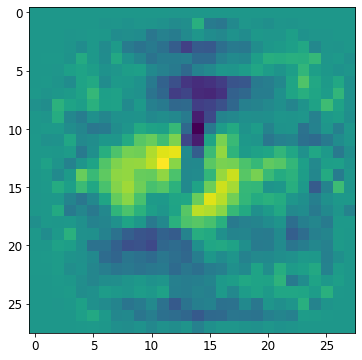

In [ ]:
image=pipe[-1].coef_[4].reshape(28,28)

plt.imshow(image)


In [ ]:
pipe[-1].intercept_

array([-0.25772504, -0.49001505,  0.23215004,  0.24497982, -0.32792409,
        0.30887949, -0.20104819, -0.25996318,  0.70634575,  0.04432048])

In [ ]:
pipe[-1].classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [ ]:
#Model evaluation 

y_pred = pipe.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.94      0.90      0.92      1032
           3       0.91      0.91      0.91      1010
           4       0.92      0.94      0.93       982
           5       0.91      0.87      0.89       892
           6       0.93      0.95      0.94       958
           7       0.92      0.93      0.92      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



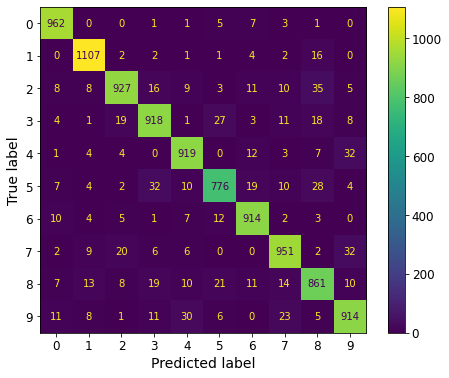

In [ ]:
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred) 

<Figure size 1440x1440 with 0 Axes>

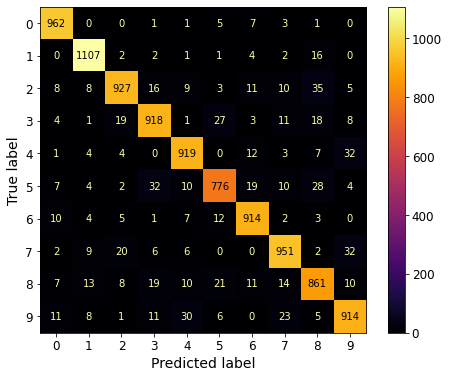

In [ ]:
plt.figure(figsize=(20,20))
ConfusionMatrixDisplay.from_estimator(pipe, x_test, y_test,cmap='inferno',values_format='.5g') 
plt.show()

In [ ]:
from sklearn.metrics import make_scorer 
from sklearn.metrics import f1_score 


x_tr,x_te,y_tr, y_te = X[:10000],X[10000:10500],y[:10000],y[10000:10500]
scorer = make_scorer(f1_score,average='micro') 
pipe = Pipeline([('scaler',StandardScaler()),
                 ('logreg',LogisticRegressionCV(cv =3, 
                multi_class = 'multinomial',solver='sag',
                scoring=scorer,max_iter =100,random_state=1729)) ])

# pipe.fit(x_tr,y_tr)


In [ ]:
# pipe[-1].C_

In [ ]:
# pipe[-1].l1_ratio_


In [ ]:
# print(classification_report(y_test, pipe.predict(x_test)))

In [ ]:
# ConfusionMatrixDisplay.from_estimator(pipe, x_test, y_test) 
# plt.show()

In [ ]:
import numpy as np  
from pprint import pprint 

np.random.seed(42) 

from sklearn.datasets import fetch_openml 

from sklearn.preprocessing import MinMaxScaler  

from sklearn.decomposition import PCA  

from sklearn.pipeline import Pipeline 

from sklearn.dummy import DummyClassifier 

from sklearn.neighbors import KNeighborsClassifier 

from sklearn.model_selection import cross_validate, RandomizedSearchCV, GridSearchCV, cross_val_predict 
from sklearn.model_selection import learning_curve 
from sklearn.pipeline import make_pipeline




In [ ]:
#Change labels to binary class with KNN and then extend it to Multiclass set up 
#initialize new variable names with all -1 

y_train_0 = -1*np.ones((len(y_train))) 
y_test_0 = -1*np.ones((len(y_test))) 


#find indices of digit 0 image 

indx_0 = np.where(y_train =='0') 
y_train_0[indx_0]=1 
indx_0 = np.where(y_test=='0') 
y_test_0[indx_0]=1

#Data Visualization in Lower dimension
* Let us apply PCA on the datapoints and reduce the dimensions to 2D and then to 3D.
* This will give us some rough idea about the points in $R^{784}$
* One interesting thing to look at is the change in the magnitude of the data points before and after applying PCA.
* We use the variables `pipe_pca_2d` for preprocessing the samples alone and `pipe_clf_pca_2d` for classification.



In [ ]:
pipe_pca_2d = make_pipeline(MinMaxScaler(),PCA(n_components=2))
x_train_pca_2d = pipe_pca_2d.fit_transform(x_train) 


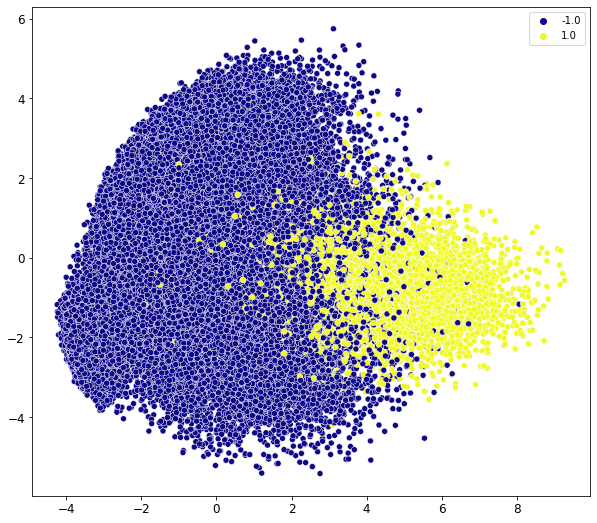

In [ ]:
#visualizing the 2D data obtained through pca() 

plt.figure(figsize=(10,9)) 
sns.scatterplot(x=x_train_pca_2d[:,0],y=x_train_pca_2d[:,1],data=x_train_pca_2d,hue=y_train_0, palette='plasma')
plt.show()

In [ ]:
pipe_pca_3d = make_pipeline(MinMaxScaler(), PCA(n_components=3))
x_train_pca_3d = pipe_pca_3d.fit_transform(x_train)
x_train_pca_3d.shape

(60000, 3)

In [ ]:
from IPython.core.pylabtools import figsize
#3D visualization 
import plotly.express as px  
fig = px.scatter_3d(x=x_train_pca_3d[:,0],y=x_train_pca_3d[:,1],
                    z=x_train_pca_3d[:,2],
                    color=y_train_0,
                    color_discrete_map = 'plasma',
                    opacity=0.5)
fig.show()


In [ ]:
#creating a new pipeline for classifier 

pipe_clf_pca_2d = make_pipeline(pipe_pca_2d,KNeighborsClassifier(n_neighbors=3))

In [ ]:
index_neg = np.argsort(y_train_0)[:5] 
index_pos = np.argsort(y_train_0)[-1:-6:-1] 

#create a small dataset 

x = np.vstack((x_train[index_pos,:],x_train[index_neg,:]))
y = np.hstack((y_train_0[index_pos],y_train_0[index_neg]))
y


array([ 1.,  1.,  1.,  1.,  1., -1., -1., -1., -1., -1.])

In [ ]:
pipe_clf_pca_2d.fit(x,y)



Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                 ('pca', PCA(n_components=2))])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=3))])

In [ ]:
x_reduced = pipe_clf_pca_2d[0].transform(x) 

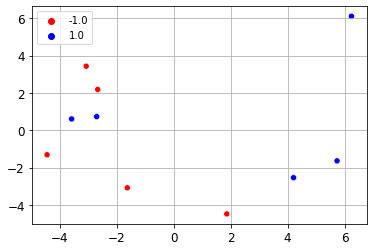

In [ ]:
plt.figure(figsize=(6,4)) 
sns.scatterplot(x=x_reduced[:,0],y=x_reduced[:,1],hue=y, marker ='o',palette=['r','b'])
plt.grid(True)
plt.show()

Test label [-1. -1. -1.  1. -1. -1. -1. -1. -1. -1.]


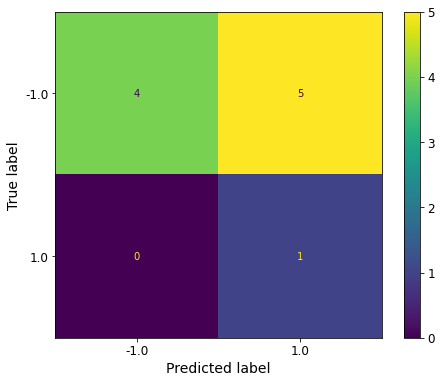

In [ ]:
y_hat_0 = pipe_clf_pca_2d.predict(x_test[:10,:])
ConfusionMatrixDisplay.from_predictions(y_test_0[:10],y_hat_0)
print('Test label',y_test_0[:10])

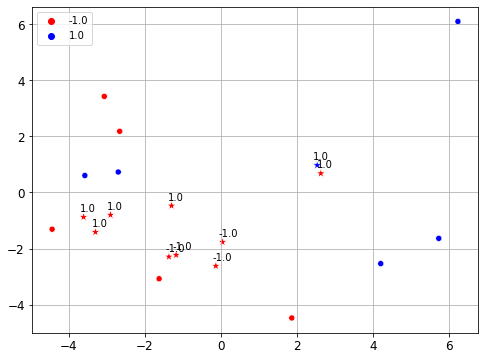

In [ ]:
cmap = mpl.colors.ListedColormap(['r','b']) 
plt.figure(figsize=(8,6)) 
sns.scatterplot(x = x_reduced[:,0], y = x_reduced[:,1],marker='o',hue=y,palette = cmap)

x_test_reduced = pipe_clf_pca_2d[0].transform(x_test[:10,:])
sns.scatterplot(x = x_test_reduced[:,0], y = x_test_reduced[:,1],s=100,marker='*', hue= y_test_0[:10],palette=cmap, legend=None)
dx,dy = -0.1,0.2 
for i in range(10):
  plt.annotate(str(y_hat_0[i]),xy = (x_test_reduced[i,0]+dx , x_test_reduced[i,1]+dy))

plt.grid(True)
plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors 
import statistics
neighbours = NearestNeighbors(n_neighbors=3) 
neighbours.fit(pipe_pca_2d.transform(x)) 

NearestNeighbors(n_neighbors=3)

In [ ]:
dist_neighbours, idx_neighbours = neighbours.kneighbors(pipe_pca_2d.transform(x_test[:10]),
                                                        3,return_distance=True)

In [ ]:
for i in range(3):
  print('Distance:{0},\nIndex:{1},\nLabels: {2} ,\nPrediction:{3}'.format(dist_neighbours[i],
                                                                         idx_neighbours[i],
                                                                         y[idx_neighbours[i].flatten()],
                                                                         statistics.mode(y[idx_neighbours[i].flatten()])))

Distance:[1.54510433 1.56004731 1.61914472],
Index:[1 4 6],
Labels: [ 1.  1. -1.] ,
Prediction:1.0
Distance:[0.95703587 3.33077652 3.39001596],
Index:[7 1 6],
Labels: [-1.  1. -1.] ,
Prediction:-1.0
Distance:[1.14297879 2.0379748  2.22709669],
Index:[6 4 1],
Labels: [-1.  1.  1.] ,
Prediction:1.0


Let us train the model with 10000 samples from training set (i.e. we are just putting 10000 datapoints in the metric space, not building any parameterized model) 


In [ ]:
pipe_clf_pca_2d.fit(x_train[:10000],y_train_0[:10000]) 

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                 ('pca', PCA(n_components=2))])),
                ('kneighborsclassifier', KNeighborsClassifier(n_neighbors=3))])

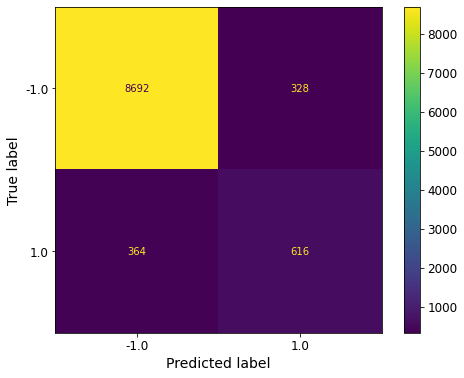

In [ ]:
y_hat_0 = pipe_clf_pca_2d.predict(x_test) 
ConfusionMatrixDisplay.from_predictions(y_test_0,y_hat_0) 
plt.show()

In [ ]:
print(classification_report(y_test_0,y_hat_0))

              precision    recall  f1-score   support

        -1.0       0.96      0.96      0.96      9020
         1.0       0.65      0.63      0.64       980

    accuracy                           0.93     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.93      0.93      0.93     10000



* Let's vary the n_neighbours from **k=1 to 19** and study the performance of the model.
* We use the first 10K samples from training set(you may increase it further upto 60K, take it as an excercise) 



In [ ]:
from sklearn.metrics import precision_score
precision=[] 
for k in range(1,20,2):
  pipe_clf_pca_2d.__n_neighbors=k 
  pipe_clf_pca_2d.fit(x_train[:10000],y_train_0[:10000]) 
  y_hat_0 = pipe_clf_pca_2d.predict(x_test) 
  precision.append(precision_score(y_test_0,y_hat_0))


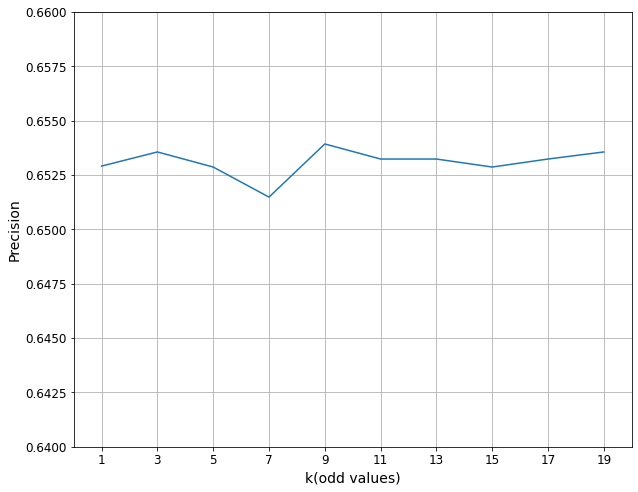

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns 
plt.figure(figsize=(10,8)) 
plt.plot(np.arange(1,20,2),precision) 
plt.xlim((0,20)) 
plt.ylim((0.64,0.66)) 
plt.xlabel('k(odd values)') 
plt.ylabel('Precision') 
plt.xticks(ticks=np.arange(1,20,2),labels=np.arange(1,20,2))
plt.grid(True)
plt.show()


Going without PCA 
* Let us use KNN classifier with all the features in the training samples. Hoping that it increases the performance of the model(of course at the cost of computation) 
* Let's search for K by using cross validation 
* Note: It takes about 20 minutes for entire computation.


In [ ]:
pipe_knn = make_pipeline(MinMaxScaler(),
                         KNeighborsClassifier(n_neighbors=1))

grid_k = {'kneighborsclassifier__n_neighbors':[1,3,5,7,9,11]}

cv = GridSearchCV(pipe_knn, param_grid= grid_k, scoring='precision',cv=5)
cv.fit(x_train,y_train_0)
print(cv)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                       ('kneighborsclassifier',
                                        KNeighborsClassifier(n_neighbors=1))]),
             param_grid={'kneighborsclassifier__n_neighbors': [1, 3, 5, 7, 9,
                                                               11]},
             scoring='precision')


In [ ]:
print(cv.cv_results_)

{'mean_fit_time': array([0.56814818, 0.50833082, 0.51362667, 0.54289389, 0.5391469 ,
       0.84539356]), 'std_fit_time': array([0.1030643 , 0.00647897, 0.00879208, 0.05849146, 0.02892916,
       0.38553681]), 'mean_score_time': array([32.18674765, 33.79576955, 37.74925976, 39.26633186, 43.57482371,
       50.72847157]), 'std_score_time': array([0.6841826 , 0.09830239, 0.3559271 , 1.92123391, 2.21832121,
       4.73979044]), 'param_kneighborsclassifier__n_neighbors': masked_array(data=[1, 3, 5, 7, 9, 11],
             mask=[False, False, False, False, False, False],
       fill_value='?',
            dtype=object), 'params': [{'kneighborsclassifier__n_neighbors': 1}, {'kneighborsclassifier__n_neighbors': 3}, {'kneighborsclassifier__n_neighbors': 5}, {'kneighborsclassifier__n_neighbors': 7}, {'kneighborsclassifier__n_neighbors': 9}, {'kneighborsclassifier__n_neighbors': 11}], 'split0_test_score': array([0.97920133, 0.98493724, 0.98166667, 0.98086522, 0.97921862,
       0.97921862]), 'sp

      `metrics.accuracy_score(y_true, y_pred, *[, ...]) 

      Accuracy classification score.

      metrics.auc(x, y)

      Compute Area Under the Curve (AUC) using the trapezoidal rule.

      metrics.average_precision_score(y_true, ...)

      Compute average precision (AP) from prediction scores.

      metrics.balanced_accuracy_score(y_true, ...)

      Compute the balanced accuracy.

      metrics.brier_score_loss(y_true, y_prob, *)

      Compute the Brier score loss.

      metrics.classification_report(y_true, y_pred, *)

      Build a text report showing the main classification metrics.

      metrics.cohen_kappa_score(y1, y2, *[, ...])

      Cohen's kappa: a statistic that measures inter-annotator agreement.

      metrics.confusion_matrix(y_true, y_pred, *)

      Compute confusion matrix to evaluate the accuracy of a classification.

      metrics.dcg_score(y_true, y_score, *[, k, ...])

      Compute Discounted Cumulative Gain.

      metrics.det_curve(y_true, y_score[, ...])

      Compute error rates for different probability thresholds.

      metrics.f1_score(y_true, y_pred, *[, ...])

      Compute the F1 score, also known as balanced F-score or F-measure.

      metrics.fbeta_score(y_true, y_pred, *, beta)

      Compute the F-beta score.

      metrics.hamming_loss(y_true, y_pred, *[, ...])

      Compute the average Hamming loss.

      metrics.hinge_loss(y_true, pred_decision, *)

      Average hinge loss (non-regularized).

      metrics.jaccard_score(y_true, y_pred, *[, ...])

      Jaccard similarity coefficient score.

      metrics.log_loss(y_true, y_pred, *[, eps, ...])

      Log loss, aka logistic loss or cross-entropy loss.

      metrics.matthews_corrcoef(y_true, y_pred, *)

      Compute the Matthews correlation coefficient (MCC).

      metrics.multilabel_confusion_matrix(y_true, ...)

      Compute a confusion matrix for each class or sample.

      metrics.ndcg_score(y_true, y_score, *[, k, ...])

      Compute Normalized Discounted Cumulative Gain.

      metrics.precision_recall_curve(y_true, ...)

      Compute precision-recall pairs for different probability thresholds.

      metrics.precision_recall_fscore_support(...)

      Compute precision, recall, F-measure and support for each class.

      metrics.precision_score(y_true, y_pred, *[, ...])

      Compute the precision.

      metrics.recall_score(y_true, y_pred, *[, ...])

      Compute the recall.

      metrics.roc_auc_score(y_true, y_score, *[, ...])

      Compute Area Under the Receiver Operating Characteristic Curve (ROC AUC) from prediction scores.

      metrics.roc_curve(y_true, y_score, *[, ...])

      Compute Receiver operating characteristic (ROC).

      metrics.top_k_accuracy_score(y_true, y_score, *)

      Top-k Accuracy classification score.

      metrics.zero_one_loss(y_true, y_pred, *[, ...])

      Zero-one classification loss`

In [ ]:
pipe_knn = make_pipeline(MinMaxScaler(),KNeighborsClassifier(n_neighbors=7))


#Performance on test set 

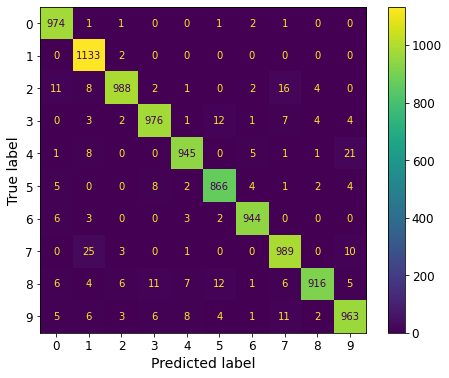

In [ ]:
pipe_knn.fit(x_train,y_train)
y_hat = pipe_knn.predict(x_test) 
ConfusionMatrixDisplay.from_predictions(y_test,y_hat)
plt.show()

#Multi-Class Classification 
* Extending KNN classifier to multi-class problem is quite straightforward.


In [ ]:
print(pipe_knn)

In [ ]:
pipe_knn.fit(x_train,y_train) 
y_hat=pipe_knn.predict(x_test) 
ConfusionMatrixDisplay.from_predictions(y_test,y_hat) 
plt.show()

In [ ]:
pipe_knn.classes_

In [ ]:
print(classification_report(y_test,y_hat))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.95      1.00      0.97      1135
           2       0.98      0.96      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.97      0.97      0.97       892
           6       0.98      0.99      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



#Overview
We know that k-NN can be used in addressing regressing problems.
In this colab, we will demonstrate use of **k-NN in regression** setup with **California housing dataset**, where we try to predict price of a house based on its features.



In [ ]:
#Scikit-learn >= 0.20 is required
import sklearn 
assert sklearn.__version__ >='0.20' 


In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.metrics import mean_squared_error 
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.preprocessing import PolynomialFeatures  

from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV 


In [ ]:
#Download the data 

X,y = fetch_california_housing(return_X_y=True) 

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, random_state=8) 



#Preprocessing the dataset 
We have explored California housing set in detail earlier in the course 

In order to refresh your memory, we have bargraphs corresponding to all the features and the output label plotted here.


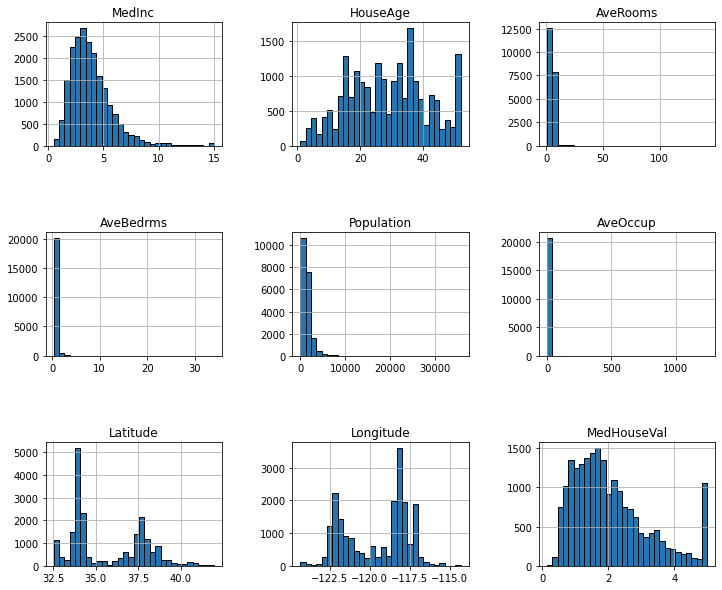

In [ ]:
california_housing = fetch_california_housing(as_frame=True) 
california_housing.frame.hist(figsize=(12,10),bins=30, edgecolor='black') 
plt.subplots_adjust(hspace=0.7,wspace=0.4)

#STEP 2: Model Building 
We instantiate a `pipeline` object with two stages; 

* The first stage performs feature scaling with `MinMaxScaler`.
* And the second stage performs k-NN regressor with `n_neighbors=2`. In short, we are using 2-NN that is we use the price of the two nearest houses in feature space to decide the price of the new house.
* The model is trained with feature matrix and label vector from training set.
After the model is trained, it is evaluated with the test set using the mean squared error metric.


In [ ]:
#Create pipeline with min_max scaler followed by 
#kNN regressor 
pipe = Pipeline([('scaler',MinMaxScaler()),
                 ('knn',KNeighborsRegressor(n_neighbors=2)) ]) 
#fitting and transform training data 

pipe.fit(X_train, y_train) 

#transform test data 
y_pred = pipe.predict(X_test) 

#compute RMSE 
error = mean_squared_error(y_test, y_pred, squared = False) 
print(error)

0.6767822465759739


#STEP 3: Model Selection and evaluation 
k-NN classifier has $k$, the number of neighbors, as a hyperparameter.
There are a couple of ways to tune the hyper-parameter 
  1. Manual hyper-parameter tuning
  2. Using `GridSearchCV` or `RandomizedSearchCV`. 
we demonstrate manual and grid search based hyperparameter tuning.

Manual HPT with cross-validation 

Here we train and evaluate the model pipeline with different values of k-1 to 31.


In [ ]:
#to store rmse values for different k
rmse_val = [] 
for K in range(1,31):

  pipe = Pipeline([('scaler',MinMaxScaler()),
                   ('knn',KNeighborsRegressor(n_neighbors=K)) ]) 
  #fit the model 
  pipe.fit(X_train, y_train) 

  #make prediction on test set 
  pred = pipe.predict(X_test) 

  #calculate rmse 
  error = mean_squared_error(y_test,pred, squared=False ) 

  #store rmse values 
  rmse_val.append(error)

At the end of this loop, we get a list of RMSEs-one for each value of k.


We plot the learning curve with k on x-axis and RMSE on y-axis 
   The  value of k that results in the lowest RMSE is the best value of k that we select.
   

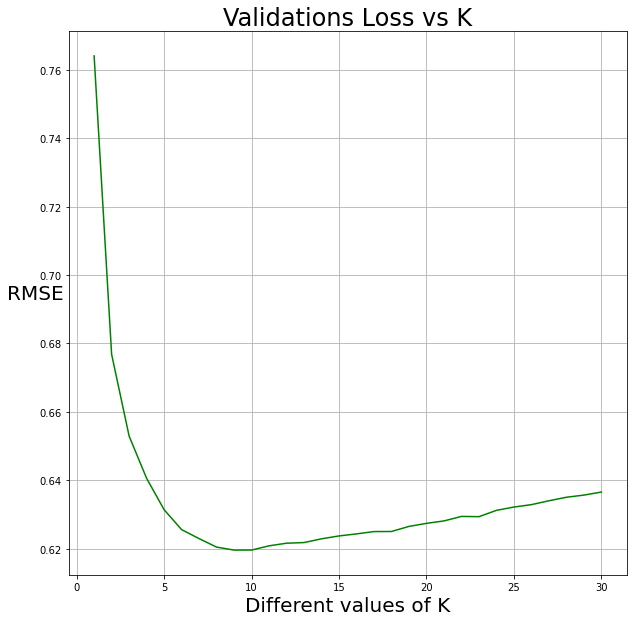

In [ ]:
plt.figure(figsize=(10,10)) 

#plotting the rmse values against k values 
plt.plot(range(1,len(rmse_val)+1),rmse_val, color='green') 

plt.xlabel('Different values of K', fontsize=20) 
plt.ylabel('RMSE',fontsize=20, rotation=0) 
plt.grid(True) 

#displaying the title 
plt.title('Validations Loss vs K',fontsize=24) 
plt.show()

In [ ]:
rmse_val.index((min(rmse_val)))

8

HPT with `GridSearchCV`
We set up the parameter grid for values of k of our interest.

   Here we use the values between 1 and 31.

   The object of `GridSearchCV` is instantiated with a `KNeighborsregressor` estimator along with the parameter grid and number of cross-validation folds equal to 10.

The grid search is performed by calling the `fit` method with training feature matrix and labels as arguments.



In [ ]:
param_grid = {'knn__n_neighbors':list(range(1,31))} 

pipe = Pipeline([('scaler',MinMaxScaler()),
                  ('knn',KNeighborsRegressor())
                ]) 

gs = GridSearchCV(pipe,param_grid = param_grid,
                  cv =10,
                  n_jobs=1,
                  return_train_score=True) 
gs.fit(X_train,y_train) 

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('knn', KNeighborsRegressor())]),
             n_jobs=1,
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29, 30]},
             return_train_score=True)

In [ ]:
reg_knn = gs.best_estimator_
print(reg_knn)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('knn', KNeighborsRegressor(n_neighbors=6))])


In [ ]:
pred = gs.best_estimator_.predict(X_test)

In [ ]:
error = mean_squared_error(y_test,pred,squared=False) 
error

0.6255268557053962

In [ ]:
param_grid = {'knn__n_neighbors':list(range(1,31))} 

pipe = Pipeline([('scaler',MinMaxScaler()),
                  ('knn',KNeighborsRegressor())
                ]) 

rs = RandomizedSearchCV(pipe, param_distributions=param_grid,
                      n_jobs=1,refit=True, cv=10,return_train_score=True) 
rs.fit(X_train,y_train) 

RandomizedSearchCV(cv=10,
                   estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                             ('knn', KNeighborsRegressor())]),
                   n_jobs=1,
                   param_distributions={'knn__n_neighbors': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10, 11,
                                                             12, 13, 14, 15, 16,
                                                             17, 18, 19, 20, 21,
                                                             22, 23, 24, 25, 26,
                                                             27, 28, 29, 30]},
                   return_train_score=True)

In [ ]:
rs.best_estimator_

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('knn', KNeighborsRegressor(n_neighbors=6))])

In [ ]:
rs.best_estimator_.predict(X_test)

array([3.16016667, 0.61716667, 1.75716667, ..., 1.527     , 2.32266667,
       1.33533333])

In [ ]:
pred= rs.best_estimator_.predict(X_test)


In [ ]:
rs.cv_results_

{'mean_fit_time': array([0.02045927, 0.01591234, 0.01618509, 0.01600502, 0.0157974 ,
        0.01591978, 0.01586919, 0.01610785, 0.01556213, 0.01611204]),
 'mean_score_time': array([0.06998301, 0.02798531, 0.05067446, 0.03273976, 0.04818552,
        0.0315058 , 0.03343387, 0.04765203, 0.05400827, 0.03597968]),
 'mean_test_score': array([0.70175169, 0.64975771, 0.69413325, 0.69381698, 0.69733519,
        0.67851149, 0.7021648 , 0.69833883, 0.69260409, 0.70620121]),
 'mean_train_score': array([0.74353023, 0.88832216, 0.7206866 , 0.8188132 , 0.72886028,
        0.84394638, 0.8028319 , 0.73141531, 0.71730865, 0.79203767]),
 'param_knn__n_neighbors': masked_array(data=[14, 2, 23, 4, 19, 3, 5, 18, 25, 6],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'params': [{'knn__n_neighbors': 14},
  {'knn__n_neighbors': 2},
  {'knn__n_neighbors': 23},
  {'knn__n_neighbors': 4},
  {'knn_

In [ ]:
rs.best_params_

{'knn__n_neighbors': 6}

#Polynomial Features 
In addition, we perform polynomial transformation on the features followed by scaling before using it in the nearest neighbor regressor.



In [ ]:
params = {'poly__degree': list(range(1,4))} 

pipe = Pipeline([('poly', PolynomialFeatures()),
                ('scaler',MinMaxScaler()),
                 ('knn',KNeighborsRegressor()) ])
gs = GridSearchCV(estimator=pipe,
                  param_grid = params,
                  cv =10,
                  n_jobs=-1) 
gs.fit(X_train, y_train)
reg_knn = gs.best_estimator_ 
print(reg_knn)

/usr/local/lib/python3.7/dist-packages/joblib/externals/loky/process_executor.py:705: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  "timeout or by a memory leak.", UserWarning


Pipeline(steps=[('poly', PolynomialFeatures(degree=1)),
                ('scaler', MinMaxScaler()), ('knn', KNeighborsRegressor())])


We evaluate the model with the test set.



In [ ]:
pred = gs.best_estimator_.predict(X_test) 
error = mean_squared_error(y_test, pred, squared=False) 
print('RMSE value of k is:', error)

RMSE value of k is: 0.6313551708664618


#Outline

In this colab, we study how to handle **large-scale datasets** in sklearn.mean_squared_error.
* In this course, so far we were able to load entire data in memory and were able to train and make inferences on all the data at once.
* The large scale data sets may not fit in memory and we need to devise strategies to handle it in the context of training and prediction use cases.

In this colab, we will discuss the following topics:

* Overview of handling large-scale data.
* Incremental preprocessing and learning.
  * `fit()` vs `partial_fit()`: `partial_fit` is our friend in this cases.

#Large-scale Machine Learning

Large-scale Machine Learning differs from traditional machine learning in the sense that it involves processing large amount of data in terms of its **size** or **number of samples, features or classes** 

There were many exciting developements in efficient large scale learning on many real world use cases in the last decade.

Although scikit-learn is optimized for **smaller data**, it does offer a decent set of **feature preprocessing** and **learning algorithms** for large scale data such as classification, regression and clustering.

Scikit-learn handles large data through `partial_fit()` method instead of using the usual `fit()` method. 

   The idea is to process data in **batches** and **update** the model parameters for each batch. This way of learning is reffered to as **Incremental(or out-or-core) learning.

#Incremental Learning 

Incremental learning may be required in the following two scenarios:
* For **out-of-memory(large) datasets,**where it's not possible to **load the entire data into the RAM** at once, one can load the data in chunks and fit the training model for each chunk of data.
* For machine learning tasks where a new batch of data comes with time,re-training the model with the previous and new batch of data is a computationally expensive process.

   Instead of re-training the model with the entire set of data, one can employ an incremental learning approach, where the model parameters are updated with the new batch of data.

##Incremental Learning in `sklearn`

TO perform incremental learning, Scikit-learn implements `partial_fit` method that helps in training an out-of-memory dataset. In other words, it has the ability to learn incrementally from a batch of instances.


In this colab,we will see an example of how to read, process, and train on such a large dataset that can't be loaded in memory entirely.

This method is expected to be called several times consecutively on different chunks of a dataset so as to implement out-of-core(online) learning. This function has some performance overhead, so it's recommended to call it on a considerable large batch of data(that fits into the memory), to overcome the limitation of overhead.

##partial_fit() attributes:

`partial_fit(X,y,[classes], [sample_weight])`

where,
* X: array of shape(n_samples, n_features) where n_samples is the number of samples of n_features is the number of features. 
* y: array of shape(n_samples,) of target values.
* `classes`: array of shape(n_classes,) containing a list of all the classes that can possibly appear in the y vector.

Must be provided at the first call to partial_fit, can be omitted in subsequet calls.

* sample_`weight`: (optional) array of shape(n_samples,) containing weights applied to individual samples(1.for unweighted)

Returns: object(self) 

for classification tasks, we have to pass the list of possible target class labels in `classes` parameter to cope-up with the unseen target classes in the 1st batch of the data.

The following estimators implement partial_fit method:

* **Classification**:
  * MultinomialNB 
  * BernoulliNB 
  * SGDClassifier
  * Perceptron 
* **Regression**:
  * SGDRegressor

* **Clustering**:
  * `MiniBatchKmean`

`SGDRegressor` and `SGDClassifier` are commonly used for handling large data.

The problem with standard regression/classification implementations such as batch gradient descent, support vector machines (SVMs), random forest etc is that because of the need to load all the data into memory at once, they can not be used in scenarios where we do not have sufficient memory. SGD, however, can deal with large data sets effectively by breaking up the data into chunks and processing them sequentially. The fact that we only need to load one chunk into memory at a time makes it useful for large-scale data as well as cases where we get streams of data at intervals.

#fit() versus partial_fit()

Below, we show the use of `partial_fit()` along with `SGDClassifier`

For illustration we first use traditional fit() and then use `partial_fit()` on the same data.

In [ ]:
#Importing Libraries 
from sklearn.linear_model import SGDClassifier 
from sklearn.datasets import make_classification 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report 



#Traditinal Approach (using `fit()`)
## Sample dataset 

We will use a synthetic classification dataset for demonstration.
Let us have 50000 samples with 10 features matrix. Further, lets have 3 classes in the target label, each class having a single cluster.



In [ ]:
x,y = make_classification(n_samples=50000, n_features=10,
                          n_classes =3,
                          n_clusters_per_class=1)

xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=0.15) 



##We will make use of `SGDClassifier` to learn the classification model.



In [ ]:
clf1 = SGDClassifier(max_iter =1000, tol=0.01)

We will use traditional `fit()` method to train out model. 


In [ ]:
clf1.fit(xtrain, ytrain)

SGDClassifier(tol=0.01)

Let's obtain the training and test scores on the trained model.



In [ ]:
train_score = clf1.score(xtrain, ytrain)
train_score

0.8332941176470589

In [ ]:
test_score = clf1.score(xtest, ytest)
test_score

0.8302666666666667

We obtain the confusion matrix and classification report for evaluating the classifier.



[[2053  445   14]
 [ 274 2149   20]
 [ 255  265 2025]]


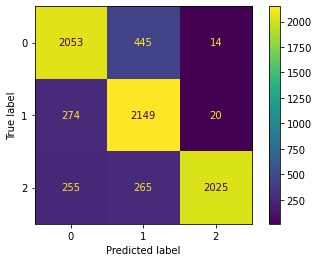

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ypred = clf1.predict(xtest) 
print(confusion_matrix(ytest, ypred))
ConfusionMatrixDisplay.from_predictions(ytest, ypred)  


In [ ]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      2512
           1       0.75      0.88      0.81      2443
           2       0.98      0.80      0.88      2545

    accuracy                           0.83      7500
   macro avg       0.84      0.83      0.83      7500
weighted avg       0.84      0.83      0.83      7500



##Incremental approach (using partial_fit()) 

We will now assume that the data can't be kept completely in the main memory and hence, will load chunks of data and fit usng `partial_fit()`.


In [ ]:
xtrain[:5]

array([[ 0.43730863, -2.76892412, -0.13160189,  2.98560933, -0.29025881,
         0.53602365, -0.48815079, -1.13060207,  0.02625099,  0.9100316 ],
       [-0.66924638, -0.53589829,  1.19075444, -0.92226969, -0.76509943,
        -0.84453671,  1.46010866, -0.0422574 , -0.8352542 , -1.29478472],
       [ 1.68873874,  1.18727072, -1.41311248, -2.29387703, -0.35459563,
        -1.31097345,  1.25982138,  0.39778013, -0.7009112 ,  1.39109616],
       [-0.72574843, -0.69292692,  0.75261709, -0.57166767, -0.69588833,
         0.3389533 ,  1.24455633,  1.63628774, -1.02605814, -0.01434957],
       [ 1.24482167, -1.10936768, -1.27850683,  0.24115398, -0.56762122,
         0.02902249,  0.79413551, -1.2473405 , -1.03542404,  0.23125699]])

In [ ]:
ytrain[:5]

array([0, 2, 1, 0, 0])

In order to load data chunk, we will first store the given(training) data in a csv file(This is just for demonstration purpose. In a  real scenario, the large dataset might already be in the form of say, a csv which we will be reading in multiple iterations.) 


In [ ]:
import numpy as np 


In [ ]:
train_data = np.concatenate((xtrain, ytrain[:,np.newaxis]),axis=1)

In [ ]:
train_data[:5]

array([[ 0.43730863, -2.76892412, -0.13160189,  2.98560933, -0.29025881,
         0.53602365, -0.48815079, -1.13060207,  0.02625099,  0.9100316 ,
         0.        ],
       [-0.66924638, -0.53589829,  1.19075444, -0.92226969, -0.76509943,
        -0.84453671,  1.46010866, -0.0422574 , -0.8352542 , -1.29478472,
         2.        ],
       [ 1.68873874,  1.18727072, -1.41311248, -2.29387703, -0.35459563,
        -1.31097345,  1.25982138,  0.39778013, -0.7009112 ,  1.39109616,
         1.        ],
       [-0.72574843, -0.69292692,  0.75261709, -0.57166767, -0.69588833,
         0.3389533 ,  1.24455633,  1.63628774, -1.02605814, -0.01434957,
         0.        ],
       [ 1.24482167, -1.10936768, -1.27850683,  0.24115398, -0.56762122,
         0.02902249,  0.79413551, -1.2473405 , -1.03542404,  0.23125699,
         0.        ]])

In [ ]:
a = np.asarray(train_data) 
np.savetxt('train_data.csv',a, delimiter=',')

Now, our data for demonstration is ready in a csv file.
Let's create `SGDClassifier` object that we intend to train with `partial_fit()`.

In [ ]:
#Let us create another classifier and we will fit it incrementally.
clf2 = SGDClassifier(max_iter=1000, tol=0.01)

##Processing data chunk by chunk 
Pandas' read_csv() function has an attribute `chunksize` that can be used to read data chunk by chunk. The `chunksize` parameter specifies the number of rows per chunk. (The last chunk may contain fewer than chunksize rows, of course.) 

We can then use this data for `partial_fit()`. We can then repeat these two steps multiple times. That way entire data may not be required to be kept in memmory.

In [ ]:
import pandas as pd
chunksize =1000 


iter =1 
for train_df in pd.read_csv('train_data.csv',chunksize=chunksize, iterator=True):
  # print(train_data.shape)
  if iter ==1:
    # print(train_df)
    # In the first iteration, we are specifying all possible class.
    # labels
    xtrain_partial = train_df.iloc[:,0:10]
    ytrain_partial = train_df.iloc[:,10]
    clf2.partial_fit(xtrain_partial,ytrain_partial,
                     classes=np.array([0,1,2])) 
    
  else:
    xtrain_partial = train_df.iloc[:,0:10]
    ytrain_partial = train_df.iloc[:,10]
    clf2.partial_fit(xtrain_partial,ytrain_partial) 
  
  print("After iter #", iter) 
  print(clf2.coef_) 
  print(clf2.intercept_) 
  iter+=1 
  



After iter # 1
[[ -4.249947   -56.74832473   7.50184493   5.97515119 -32.04194827
    6.28425568  47.21480416   8.65053677   1.17358781  -6.77193466]
 [  5.99160765  16.39744558  -3.34892681 -28.71708711  -3.49672305
  -27.62469908  14.32806538 -14.79664114  -1.89455268  -8.64959939]
 [ -1.35643743  -9.85212844  -1.97080672  26.41298681   6.42923505
    0.49643474 -18.10021172   0.30137165  11.22965608  -5.90712757]]
[-82.31447031 -41.98927477 -10.43802809]
After iter # 2
[[ -4.22930432 -38.62073841   0.35123003   9.52506917 -19.2268835
   -6.74582295  26.4757357   -3.69516927  -2.39747707  -0.15264583]
 [  2.31435401  12.61524909  -8.28843344  -1.05227202   7.25341894
   -6.51682866 -10.78196967   4.98846938   0.25745166  -6.20792181]
 [  5.41840496   7.70757346   9.66760368   9.26989756   9.11625492
    1.75000837 -16.86030592  -1.06809421   7.79682186  -4.46728055]]
[-75.05463132 -13.98296396 -16.40398943]
After iter # 3
[[ -4.04189486 -31.93901186  -5.01061013   7.87894703 -15.8996

Notes:
* In the first call to `partial_fit()`, we passed the list of possible target class labels. For subsequent calls to `partial_fit()`, this is not required.

* Observe the changing values pf the classifier attributes: `coef_` and `intercept_` which we are printing in each iteration.


In [ ]:
test_score = clf2.score(xtest, ytest) 
test_score

/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  "X does not have valid feature names, but"


0.8117333333333333

Let's evaluate the classifier by examining the `confusion_matrix`.


/usr/local/lib/python3.7/dist-packages/sklearn/base.py:451: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  "X does not have valid feature names, but"


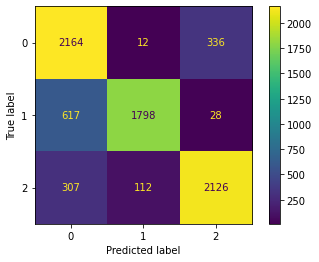

In [ ]:
ypred = clf2.predict(xtest) 
cm = confusion_matrix(ytest, ypred)
ConfusionMatrixDisplay.from_predictions(ytest,ypred)

In [ ]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.70      0.86      0.77      2512
           1       0.94      0.74      0.82      2443
           2       0.85      0.84      0.84      2545

    accuracy                           0.81      7500
   macro avg       0.83      0.81      0.81      7500
weighted avg       0.83      0.81      0.81      7500



Apart from `SGDClassifier`, we can also train `Perceptron()`, `MultinomialNB()`, in a similar manner.


# Incremental Preprocessing Example 

### `CountVectorizer vs HashingVectorizer` 

Vectorizers are used to convert a collection of text documents to a vector representation, thus helping in preprocessing them before applying any model on these text documents.

`CountVectorizer` and `HashingVectorizer` both perform the task of vectorizing the text documents. However, there are some differences among them.

One difference is that `HashingVectorizer` does not store the resulting vocabulary(i.e. the unique tokens). Hence, it can be used to learn from data that does not fit into the computer's main memory. Each mini-batch is vectorized using `HashingVectorizer` so as to guarantee that the input space of the estimator has always the same dimensionality.

With `HashingVectorizer`, each token directly maps to a pre-defined column position in a matrix. For example, if there are 100 columns in the resultant(vectorized) matrix, each token(word) maps to 1 of the 100 columns. The mapping between the word and the position in matrix is done using hashing.


In other words in `HashingVectorizer`, each token transforms to a column position instead of adding to the vocabulary. Not storing the vocabulary is useful while handling large datasets. This is because holding a huge token vocabulary compromising of millions of words may be a challenging when the memory is limited.

Since `HashingVectorizer` does not store vocabulary. Its object not only takes lesser space. It also alleviates any dependence with function calls performed on the previous chunk of data in case of incremental learning.

##Example

Let us take some sample text documents and vectorize them, first using CountVectorizer and then HashingVectorizer.





In [ ]:
text_documents = ['The well-known saying an apple a day keeps the doctor away has a very straightforward, literal meaning, that the eating of fruit maintains good health.',
                  'The proverb fist appeared in print in 1866 and over 150 years later is advice that we still pass down through generation.',
                  'British apples are one of the nations best loved fruit and according to Great British Apples, we consume around 122,000 tonnes of them each year.',
                  'But what are the health benefits, and do they really keep the doctor away?']

# 1. CountVectorizer 

We will first import the library and then create an object of CountVectorizer class.



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer 
c_vectorizer = CountVectorizer() 


We will now use this object to vectorize the input text documents using the function `fit_transform()`.


In [ ]:
X_c = c_vectorizer.fit_transform(text_documents) 
X_c.shape

(4, 66)

Here, 66 is the size of the vocabulary.

We can also see the vocabulary using `vocabulary_` attribute.

In [ ]:
c_vectorizer.vocabulary_

{'000': 0,
 '122': 1,
 '150': 2,
 '1866': 3,
 'according': 4,
 'advice': 5,
 'an': 6,
 'and': 7,
 'appeared': 8,
 'apple': 9,
 'apples': 10,
 'are': 11,
 'around': 12,
 'away': 13,
 'benefits': 14,
 'best': 15,
 'british': 16,
 'but': 17,
 'consume': 18,
 'day': 19,
 'do': 20,
 'doctor': 21,
 'down': 22,
 'each': 23,
 'eating': 24,
 'fist': 25,
 'fruit': 26,
 'generation': 27,
 'good': 28,
 'great': 29,
 'has': 30,
 'health': 31,
 'in': 32,
 'is': 33,
 'keep': 34,
 'keeps': 35,
 'known': 36,
 'later': 37,
 'literal': 38,
 'loved': 39,
 'maintains': 40,
 'meaning': 41,
 'nations': 42,
 'of': 43,
 'one': 44,
 'over': 45,
 'pass': 46,
 'print': 47,
 'proverb': 48,
 'really': 49,
 'saying': 50,
 'still': 51,
 'straightforward': 52,
 'that': 53,
 'the': 54,
 'them': 55,
 'they': 56,
 'through': 57,
 'to': 58,
 'tonnes': 59,
 'very': 60,
 'we': 61,
 'well': 62,
 'what': 63,
 'year': 64,
 'years': 65}

Following is the representation of four text documents.


In [ ]:
print(X_c)

  (0, 54)	3
  (0, 62)	1
  (0, 36)	1
  (0, 50)	1
  (0, 6)	1
  (0, 9)	1
  (0, 19)	1
  (0, 35)	1
  (0, 21)	1
  (0, 13)	1
  (0, 30)	1
  (0, 60)	1
  (0, 52)	1
  (0, 38)	1
  (0, 41)	1
  (0, 53)	1
  (0, 24)	1
  (0, 43)	1
  (0, 26)	1
  (0, 40)	1
  (0, 28)	1
  (0, 31)	1
  (1, 54)	1
  (1, 53)	1
  (1, 48)	1
  :	:
  (2, 39)	1
  (2, 4)	1
  (2, 58)	1
  (2, 29)	1
  (2, 18)	1
  (2, 12)	1
  (2, 1)	1
  (2, 0)	1
  (2, 59)	1
  (2, 55)	1
  (2, 23)	1
  (2, 64)	1
  (3, 54)	2
  (3, 21)	1
  (3, 13)	1
  (3, 31)	1
  (3, 7)	1
  (3, 11)	1
  (3, 17)	1
  (3, 63)	1
  (3, 14)	1
  (3, 20)	1
  (3, 56)	1
  (3, 49)	1
  (3, 34)	1


#HashingVectorizer 

Let us now see how `HashingVectorizer` is different from `CountVectorizer`.

We will create an object of `HashingVectorizer`. While creating the object, we need to specify the number of features we wish to have in the feature matrix.


In [ ]:
from sklearn.feature_extraction.text import HashingVectorizer

Let us create an object of `HashingVectorizer` class. An important parameter of this class is `n_features`. It declares the number of features (columns) in the output feature matrix.

Note: Small numbers of features are likely to cause hash collisions, but large numbers will cause larger coefficient dimensions in linear learners.

In [ ]:
h_vectorizer = HashingVectorizer(n_features=50) 


Let's perform hashing vectorization with `fit_transform`.

In [ ]:
X_h = h_vectorizer.fit_transform(text_documents)

Let us examine the shape of the transformed feature matrix, The number of columns in this matrix is equal to the `n_features` attribute we specified.

In [ ]:
X_h.shape

(4, 50)

Let's print the representations of the first example 


In [ ]:
print(X_h[0])

  (0, 5)	0.0
  (0, 8)	-0.47140452079103173
  (0, 10)	-0.23570226039551587
  (0, 11)	-0.23570226039551587
  (0, 13)	0.0
  (0, 18)	-0.23570226039551587
  (0, 20)	0.23570226039551587
  (0, 26)	0.0
  (0, 29)	0.23570226039551587
  (0, 33)	0.23570226039551587
  (0, 36)	-0.23570226039551587
  (0, 38)	0.47140452079103173
  (0, 39)	-0.23570226039551587
  (0, 45)	-0.23570226039551587
  (0, 46)	0.23570226039551587


Overall, `HashingVectorizer` is a good choice if we are falling short of memory and resources, or we need to perform incremental learning. However, `CountVectorizer` is a good choice if we need to access the actual tokens.

1. Downloading the dataset

Below, we download a dataset from UCI ML datasets's library.(Instead of downloading, unzipping and then reading, we are directly reading the zipped csv file. For that purpose, we are making use of `urllib.request`, `BytesIO` and `TextIOWrapper` classes)


This is a sentiment analysis dataset. There are only two columns in the dataset. One for the textual review and the other for the sentiment.

In [ ]:
import pandas as pd 
from io import StringIO, BytesIO, TextIOWrapper 
from zipfile import ZipFile 
import urllib.request

resp = urllib.request.urlopen('https://archive.ics.uci.edu/ml/machine-learning-databases/00331/sentiment%20labelled%20sentences.zip')
zipfile = ZipFile(BytesIO(resp.read()))

data = TextIOWrapper(zipfile.open('sentiment labelled sentences/amazon_cells_labelled.txt'),encoding='utf-8') 

df = pd.read_csv(data, sep='\t') 
df.columns = ['review','sentiment']

#Exploring the data set.

Let's explore the dataset a bit.


In [ ]:
df.head()

,review,sentiment
0,"Good case, Excellent value.",1
1,Great for the jawbone.,1
2,Tied to charger for conversations lasting more...,0
3,The mic is great.,1
4,I have to jiggle the plug to get it to line up...,0


In [ ]:
df.tail()

,review,sentiment
994,The screen does get smudged easily because it ...,0
995,What a piece of junk.. I lose more calls on th...,0
996,Item Does Not Match Picture.,0
997,The only thing that disappoint me is the infra...,0
998,"You can not answer calls with the unit, never ...",0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     999 non-null    object
 1   sentiment  999 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 15.7+ KB


In [ ]:
df.describe()

,sentiment
count,999.000000
mean,0.500501
std,0.500250
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


As we can see, 
* There are 999 samples in the dataset.
* The possible classes for sentiment are 1 and 0.

#4. Splitting data into train and test


In [ ]:
from sklearn.model_selection import train_test_split 


In [ ]:
X = df.loc[:,'review']
# X2 = df.iloc[:,0]

y = df.loc[:,'sentiment'] 


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

In [ ]:
X_train.shape

(799,)

In [ ]:
y_train.shape

(799,)

#5. Preprocessing 

Since the data is textual, we need to vectorize it. In order to perform incremental learning, we will use `HashingVectorizer`. 

In [ ]:
from sklearn.feature_extraction.text import HashingVectorizer 
vectorizer = HashingVectorizer() 


#6. Creating an instance of the SGDClassifier 


In [ ]:
from sklearn.linear_model import SGDClassifier  
classifier = SGDClassifier(penalty='l2', loss = 'hinge')

#7. Iteration 1 of partial_fit() 

We will assume we do not have sufficient memory to handle all the 799 samples in one go for training purpose. So, we will take the first 400 samples from the training data and `partial_fit()` our classifier.


Another use case of partial_fit here could also be a scenario where we only have 400 samples available at a time. So, we fit our classifier with them. However, we `partial_fit` it, to have the possibility of traning it with more data later whenever that becomes available.


In [ ]:
X_train_part1_hashed = vectorizer.fit_transform(X_train[0:400]) 
y_train_part1 = y_train[0:400] 


In [ ]:
all_classes = np.unique(df.loc[:,'sentiment']) #we need to mention all classes in the first iteration of partial_fit() 


In [ ]:
classifier.partial_fit(X_train_part1_hashed, y_train_part1, classes = all_classes)

SGDClassifier()

Let us now use this classifier on our test data that we had kept aside earlier.


In [ ]:
X_test_hashed = vectorizer.transform(X_test)#first we will have to preprocess the X_test with the same vectorizer that was fit on the train data.

In [ ]:
test_score = classifier.score(X_test_hashed, y_test)
print('Test score ', test_score)

Test score  0.72


Note: We can also store this classifier using pickle object and can access it later.

#8. Iteration 2 of partial_fit()

We will now assume that more data became available. So, we will fit the same  classifier with more data and observe if our test score improves.

In [ ]:
X_train_part2_hashed = vectorizer.fit_transform(X_train[400:])
y_train_part2 = y_train[400:]

In [ ]:
classifier.partial_fit(X_train_part2_hashed, y_train_part2)

SGDClassifier()

In [ ]:
test_score = classifier.score(X_test_hashed, y_test)
print("test score:", test_score)

test score: 0.735


We see that our test score has improved after we fed more data to the classifier in the second iteration of `partial_fit()`.

